### Modelo de hipótesis, parte 2.

### Importación de librerías.

In [13]:
import __main__
from modelo_c import ModeloEnsambladoFraude
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report, average_precision_score, ConfusionMatrixDisplay

### Importación de datos.

In [2]:
df = pd.read_csv('datos_sinteticos.csv', sep=";")
df.head(2)

,cliente_id,fechas_hora,montos,tipos_establecimiento,historico_establecimiento,es_anomalia,tipo_anomalia,promedio,desviacion,maximo,minimo,monto_hora,moda_establecimiento,cantidad_establecimiento
0,1,"['2026-06-08 00:16:00', '2026-06-08 06:14:00',...","['705.29', '628.12', '272.24', '382.26', '1109...","['Farmacia', 'Farmacia', 'Transporte', 'Farmac...","['0.16643057183060853', '0.017594963536259', '...",0,Normal,879.374333,602.582962,2380.04,240.25,34.208766,Farmacia,7
1,2,"['2026-06-14 07:11:00', '2026-06-15 07:48:00',...","['266.04', '518.87', '266.71', '193.6', '264.7...","['Otros', 'Otros', 'Transporte', 'Transporte',...","['0.001894439046728334', '0.01438288653067728'...",0,Normal,346.078000,165.763599,762.78,63.60,16.192467,Otros,5


### Eliminando variables no útiles.

In [3]:
df = df.drop(columns=['cliente_id', 'promedio', 'desviacion', 'maximo', 'minimo', 'monto_hora', 'moda_establecimiento', 'cantidad_establecimiento'])
df.head(2)

,fechas_hora,montos,tipos_establecimiento,historico_establecimiento,es_anomalia,tipo_anomalia
0,"['2026-06-08 00:16:00', '2026-06-08 06:14:00',...","['705.29', '628.12', '272.24', '382.26', '1109...","['Farmacia', 'Farmacia', 'Transporte', 'Farmac...","['0.16643057183060853', '0.017594963536259', '...",0,Normal
1,"['2026-06-14 07:11:00', '2026-06-15 07:48:00',...","['266.04', '518.87', '266.71', '193.6', '264.7...","['Otros', 'Otros', 'Transporte', 'Transporte',...","['0.001894439046728334', '0.01438288653067728'...",0,Normal


### Separando las variables predictoras de la objetivo.

In [4]:
X = df.drop(columns = ['es_anomalia'])
y = df['es_anomalia']

### Separación del conjunto de prueba y entrenamiento.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=0, stratify=X['tipo_anomalia'])

### Importación del modelo.

In [6]:
modelo = ModeloEnsambladoFraude(umbral=0.50, batch_size=256)

### Resultados.

In [7]:
resultados = modelo.predict(X_test)

In [9]:
resultados.head(2)

,prob_transaccion_corta,etiqueta_transaccion_corta,prob_orden_no_congruente,etiqueta_orden_no_congruente,prob_establecimiento_raro,etiqueta_establecimiento_raro,probabilidad_mayor,codigo_final,prediccion_final
37437,0.000029,0,0.942892,1,0.187749,0,0.942892,2,orden_no_congruente
86866,0.000212,0,0.001157,0,0.039152,0,0.039152,0,Normal


### Métricas del modelo.

In [11]:
y_pred = resultados['codigo_final'] >= 1
y_prob = resultados['probabilidad_mayor']

In [12]:
print('Reporte de clasificación')
print(classification_report(y_test, y_pred))
pr_auc = average_precision_score(y_test, y_prob)
print(f"PR-AUC en prueba: {pr_auc:.4f}")

Reporte de clasificación
              precision    recall  f1-score   support

           0       0.99      0.94      0.97     17987
           1       0.66      0.94      0.77      2013

    accuracy                           0.94     20000
   macro avg       0.82      0.94      0.87     20000
weighted avg       0.96      0.94      0.95     20000

PR-AUC en prueba: 0.9076


### Matriz de confusión.

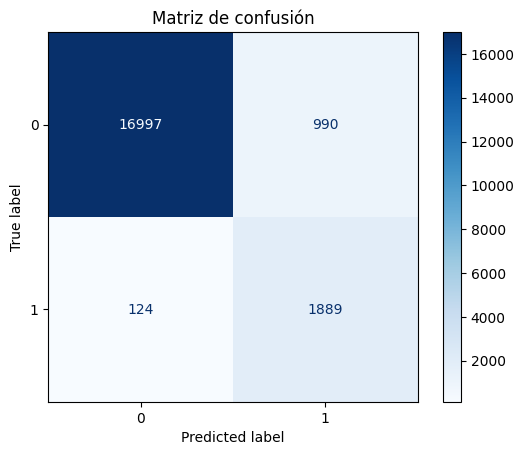

In [14]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.title("Matriz de confusión")
plt.show()